<a href="https://colab.research.google.com/github/Not-kh-lily-23/EcoSpike-Audio/blob/main/baseline_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
import os
import urllib.request
import zipfile
import pandas as pd
drive.mount('/content/drive')
project='/content/drive/MyDrive/EcoSpike'
os.makedirs(project,exist_ok=True)
os.chdir(project)
if not os.path.exists('ESC-50-master'):
    urllib.request.urlretrieve('https://github.com/karolpiczak/ESC-50/archive/master.zip','esc50.zip')
    with zipfile.ZipFile('esc50.zip','r') as zip_ref:
        zip_ref.extractall('.')
    os.remove('esc50.zip')
    print("dataset in drive")
else:
    print("dataset already in Drive.")
df=pd.read_csv('ESC-50-master/meta/esc50.csv')
t_classes={
    41:'chainsaw',
    40:'helicopter',
    44:'engine',
    14:'chirping_birds',
    7:'insects',
    10:'rain',
    16:'wind'
}
df_filt=df[df['target'].isin(t_classes.keys())].copy()
df_trn=df_filt[df_filt['fold']<5]
df_tst=df_filt[df_filt['fold']==5]
print(f"total training clips (folds 1-4): {len(df_trn)}")
print(f"total test clips (fold 5): {len(df_tst)}")
print("target class breakdown:")
print(df_filt['category'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
dataset already in Drive.
total training clips (folds 1-4): 224
total test clips (fold 5): 56
target class breakdown:
category
chirping_birds    40
chainsaw          40
wind              40
helicopter        40
rain              40
insects           40
engine            40
Name: count, dtype: int64


spectrogram tensor shape: torch.Size([1, 64, 1379])
mapped label id: 3 (original esc-50 id: 14)


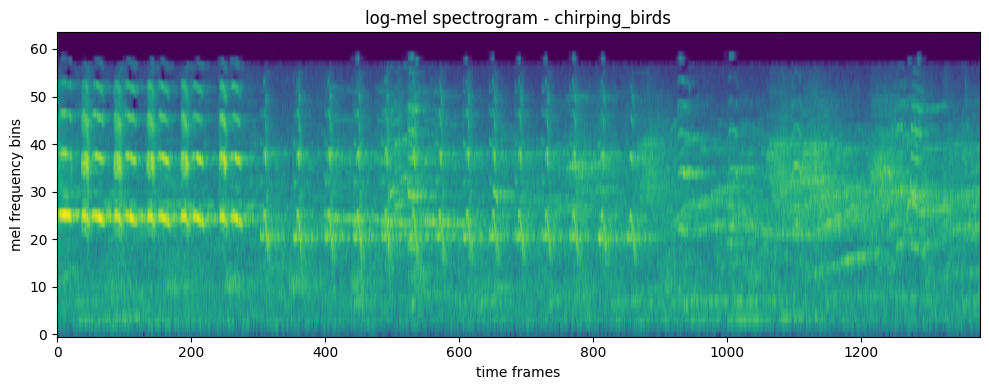

In [6]:
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os
lbl_map={original: new for new,original in enumerate(t_classes.keys())}
reverse_lbl_map={new: original for new,original in enumerate(t_classes.keys())}
class eco_spike_dset(Dataset):
    def __init__(self,df,audio_dir,transform=None):
        self.df=df.reset_index(drop=True)
        self.audio_dir=audio_dir
        self.transform=transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self,idx):
        f_name=self.df.loc[idx,'filename']
        f_path=os.path.join(self.audio_dir,f_name)
        waveform,sr=torchaudio.load(f_path)
        if sr!=16000:
            resmpl=torchaudio.transforms.Resample(orig_freq=sr,new_freq=16000)
            wavefor=resmpl(waveform)
        if self.transform:
            spectro=self.transform(waveform)
        og_lbl=self.df.loc[idx,'target']
        mapped_lbl=lbl_map[og_lbl]
        return spectro,mapped_lbl
mel_transform=torchaudio.transforms.MelSpectrogram(sample_rate=16000,n_mels=64,n_fft=400,hop_length=160)
trn_dset=eco_spike_dset(df=df_trn,audio_dir='ESC-50-master/audio',transform=mel_transform)
spec,label=trn_dset[0]
print(f"spectrogram tensor shape: {spec.shape}")
print(f"mapped label id: {label} (original esc-50 id: {reverse_lbl_map[label]})")
plt.figure(figsize=(10,4))
plt.imshow(torch.log(spec[0]+1e-6).numpy(),cmap='viridis',origin='lower',aspect='auto')
plt.title(f'log-mel spectrogram - {t_classes[reverse_lbl_map[label]]}')
plt.ylabel('mel frequency bins')
plt.xlabel('time frames')
plt.tight_layout()
plt.show()